In [ ]:
#@title Setup: connect Drive and copy data
# --- SETUP: run this first every session ---
from google.colab import drive
import os

drive.mount("/content/drive")

# Copy the data from Drive to Colab's fast disk (skips if already copied)
if not os.path.exists("/content/NPPAD"):
    !cp -r /content/drive/MyDrive/NPPAD /content/NPPAD
    print("Data copied!")
else:
    print("Data already here, skipping copy.")

Mounted at /content/drive
Data copied!


In [ ]:
import numpy as np
import pandas as pd
import joblib
import glob, os, re

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras import layers, models

# -------------------------
# CONFIG
# -------------------------
TIME_COL = "TIME"
# Number of samples are inside each window
T = 12
# How far the window moves at each step
STRIDE = 5 #cuts memory use
BATCH = 128
EPOCHS = 30
SEED = 42
rng = np.random.default_rng(SEED)

BASE_DIR = "/content/NPPAD/Operation_csv_data/"

# 0 means non-leak, 1 means leak
# Which folders count as leaks (1) and which don't (0)
LABELS = {
    # leaks
    "LOCA": 1, "LOCAC": 1, "SGATR": 1, "SGBTR": 1,
    "SLBIC": 1, #"SLBOC": 1 -- might have an error with the simulator data,
    "FLB": 1, "LLB": 1,
    # non-leaks
    "Normal": 0, "TT": 0, "SP": 0, "ATWS": 0, "LACP": 0, "LOF": 0,
    "RW": 0, "RI": 0, "MD": 0, "LR": 0,
}

# Set to a small number (e.g. 5) for a quick test run; None = use every file
MAX_PER_TYPE = None

def file_number(path):
    nums = re.findall(r"-?\d+", os.path.basename(path))
    return int(nums[0]) if nums else 0

runs = []
for folder, label in LABELS.items():
    files = sorted(glob.glob(f"{BASE_DIR}{folder}/*.csv"), key=file_number)
    if MAX_PER_TYPE:
        files = files[:MAX_PER_TYPE]
    for path in files:
        runs.append((path, label, f"{folder}{file_number(path)}"))

print(f"Found {len(runs)} recordings")

# ----------------------------------------------------------------------------------------#
#                                  1. DATA PRE-PROCESSING                                 #
# ----------------------------------------------------------------------------------------#

# -------------------------
# Helpers
# -------------------------
# Load csv into dataframe
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df

# Keep only numeric columns except TIME
def get_numeric_feature_cols(df: pd.DataFrame) -> list[str]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in numeric_cols if c != TIME_COL]
    return cols

# Turn time-series data into a supervised learning dataset
def make_windows(x: np.ndarray, T: int, stride: int) -> np.ndarray:
    N, F = x.shape
    if N < T:
        return np.empty((0, T, F), dtype=np.float32)
    idxs = range(0, N - T + 1, stride)
    return np.stack([x[i:i+T] for i in idxs], axis=0).astype(np.float32)

# -------------------------
# Load all runs + choose common feature columns (intersection)
# -------------------------
dfs = []
all_feature_sets = []

for path, y, name in runs:
    df = load_df(path)
    cols = get_numeric_feature_cols(df)
    if len(cols) == 0:
        raise ValueError(f"No numeric sensor columns found (excluding {TIME_COL}) in {path}.")
    dfs.append((df, path, y, name))
    all_feature_sets.append(set(cols))

# Use intersection so every run has same feature columns
feature_cols_ref = sorted(list(set.intersection(*all_feature_sets)))
if len(feature_cols_ref) == 0:
    raise ValueError("No common numeric feature columns across runs. Check CSV headers.")

# Remove gauges a real plant wouldn't have (they measure the leak directly)
CHEAT_COLS = [
    "WLR", "WTRA", "WTRB", "WBK", "WFLB",  # leak / break flow rates
    "MBK", "EBK", "HLW",                    # break mass, energy, leak heat content
    "RBLK", "SGLK",                         # total leaked amounts
    "STRB", "STSG", "STTB",                 # radioactivity release rates (calculated)
    "DTHY", "DWB",                          # dose to the public (calculated)
]
feature_cols_ref = [c for c in feature_cols_ref if c not in CHEAT_COLS]
print(f"Using {len(feature_cols_ref)} features after removing cheat gauges")

# -------------------------
# Build windows for each run
# -------------------------
run_windows = []  # list of (Xw, yw, run_name)
for df, path, y, name in dfs:
    x = df[feature_cols_ref].astype(np.float32).values  # (N,F)
    Xw = make_windows(x, T=T, stride=STRIDE)            # (W,T,F)
    if Xw.shape[0] == 0:
        print(f"Skipping {name}: only {len(x)} readings (need {T})")
        continue
    yw = np.full((Xw.shape[0],), y, dtype=np.int32)
    run_windows.append((Xw, yw, name))

# -------------------------
# Prototype split (time-based within each run)
# -------------------------
def split_windows_timewise(Xw, yw, train_frac=0.7, val_frac=0.15):
    W = Xw.shape[0]
    i1 = int(train_frac * W)
    i2 = int((train_frac + val_frac) * W)
    X_train, y_train = Xw[:i1], yw[:i1]
    X_val,   y_val   = Xw[i1:i2], yw[i1:i2]
    X_test,  y_test  = Xw[i2:], yw[i2:]
    return X_train, y_train, X_val, y_val, X_test, y_test


# Group recordings by event type

by_type = defaultdict(list)
for Xw, yw, name in run_windows:
    by_type[re.sub(r"-?\d+$", "", name)].append((Xw, yw, name))

X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []
train_names, val_names, test_names = [], [], []          # NEW: names for every pile

for event_type, items in by_type.items():
    if len(items) == 1:
        Xw, yw, name = items[0]
        Xt, yt, Xv, yv, Xte, yte = split_windows_timewise(Xw, yw)
        X_train_list.append(Xt); y_train_list.append(yt); train_names += [name] * len(yt)
        X_val_list.append(Xv);   y_val_list.append(yv);   val_names   += [name] * len(yv)
        X_test_list.append(Xte); y_test_list.append(yte); test_names  += [name] * len(yte)
        continue
    order = rng.permutation(len(items))
    n_test = max(1, round(0.15 * len(items)))
    n_val  = max(1, round(0.15 * len(items)))
    for k, idx in enumerate(order):
        Xw, yw, name = items[idx]
        if k < n_test:
            X_test_list.append(Xw); y_test_list.append(yw); test_names += [name] * len(yw)
        elif k < n_test + n_val:
            X_val_list.append(Xw);  y_val_list.append(yw);  val_names  += [name] * len(yw)
        else:
            X_train_list.append(Xw); y_train_list.append(yw); train_names += [name] * len(yw)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_val   = np.concatenate(X_val_list, axis=0)
y_val   = np.concatenate(y_val_list, axis=0)
X_test  = np.concatenate(X_test_list, axis=0)
y_test  = np.concatenate(y_test_list, axis=0)

print("Shapes:")
print("train:", X_train.shape, y_train.shape, "class counts:", np.bincount(y_train))
print("val  :", X_val.shape,   y_val.shape,   "class counts:", np.bincount(y_val) if len(y_val) else "[]")
print("test :", X_test.shape,  y_test.shape,  "class counts:", np.bincount(y_test))

# -------------------------
# Scale
# -------------------------
Wtr, Ttr, Ftr = X_train.shape
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, Ftr))

def scale_windows(Xw):
    W, Tt, F = Xw.shape
    Xflat = Xw.reshape(-1, F)
    Xflat = scaler.transform(Xflat)
    return Xflat.reshape(W, Tt, F).astype(np.float32)

X_train_s = scale_windows(X_train)
X_val_s   = scale_windows(X_val) if len(X_val) else X_val
X_test_s  = scale_windows(X_test)

# -------------------------
# Class weights
# -------------------------
classes_present = np.unique(y_train)
if len(classes_present) == 2:
    cw = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=y_train)
    class_weight = {0: cw[0], 1: cw[1]}
else:
    # Shouldn't happen with the timewise split, but just in case
    class_weight = None
print("class_weight:", class_weight)

# ----------------------------------------------------------------------------------------#
#                                      2. MODELLING                                       #
# ----------------------------------------------------------------------------------------#

# -------------------------
# Build the model
# -------------------------
model = models.Sequential([
    layers.Input(shape=(T, len(feature_cols_ref))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

# -------------------------
# Compile the model
# -------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),             # how well it separates classes
        tf.keras.metrics.Precision(name="precision"), # how many predicted leaks are correct
        tf.keras.metrics.Recall(name="recall"),       # how many actual leaks are caught
        tf.keras.metrics.BinaryAccuracy(name="acc"),
    ]
)

# ---------------------------------------------
# Stop early if it doesn't improve for 5 epochs
# ---------------------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)
]

# -------------------------
# Train the model
# -------------------------
history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# ----------------------------------------------------------------------------------------#
#                                  3. EVALUATE                                            #
# ----------------------------------------------------------------------------------------#
# Gets preformance metrics of the trained model on test data
proba = model.predict(X_test_s, batch_size=BATCH, verbose=0).reshape(-1)
y_pred = (proba >= 0.5).astype(np.int32)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["non-leak", "leak"]))

# ----------------------------------------------------------------------------------------#
#                                      4. SAVE                                            #
# ----------------------------------------------------------------------------------------#
model.save("lstm_leak_classifier.keras")
# Saves the trained model
joblib.dump(scaler, "scaler.pkl")
# Saves the scaler
joblib.dump({
    "feature_cols": feature_cols_ref,
    "time_steps": T,
    "stride": STRIDE
}, "config.pkl")

Found 1117 recordings
Using 81 features after removing cheat gauges
Skipping RI-100: only 11 readings (need 12)
Skipping RI-99: only 11 readings (need 12)
Skipping RI-98: only 11 readings (need 12)
Skipping RI-97: only 11 readings (need 12)
Skipping RI-96: only 11 readings (need 12)
Skipping RI-95: only 11 readings (need 12)
Skipping RI-94: only 11 readings (need 12)
Skipping RI-93: only 11 readings (need 12)
Skipping RI-92: only 11 readings (need 12)
Skipping RI-91: only 11 readings (need 12)
Skipping RI-90: only 11 readings (need 12)
Skipping RI-89: only 11 readings (need 12)
Skipping RI-88: only 11 readings (need 12)
Skipping RI-87: only 11 readings (need 12)
Skipping RI-86: only 11 readings (need 12)
Skipping RI-85: only 11 readings (need 12)
Skipping RI-84: only 11 readings (need 12)
Skipping RI-83: only 11 readings (need 12)
Shapes:
train: (61347, 12, 81) (61347,) class counts: [21426 39921]
val  : (12687, 12, 81) (12687,) class counts: [4416 8271]
test : (12994, 12, 81) (12994,)

['config.pkl']

In [ ]:
#@title Leak location model v2: trained on the first minutes of each leak

WHERE = {
    "No leak": "-",
    "LOCA":  "Hot-leg pipe (containment)",
    "LOCAC": "Cold-leg pipe (containment)",
    "SGATR": "Steam generator A tubes",
    "SGBTR": "Steam generator B tubes",
    "SLBIC": "Steam line inside containment",
    "FLB":   "Feedwater line",
    "LLB":   "Letdown line (auxiliary building)",
}
wrong = r[r.real != r.predicted]
print(wrong.assign(real_place=wrong.real.map(WHERE), predicted_place=wrong.predicted.map(WHERE)).to_string())

loc2.save("lstm_leak_location_v2.keras")
print("Saved lstm_leak_location_v2.keras")

LEAK_CLASSES = ["LOCA", "LOCAC", "SGATR", "SGBTR", "SLBIC", "FLB", "LLB"]
N_EARLY = 6          # first 6 clips = first ~6 minutes after the leak starts

def early_leak_clips(X_s, names):
    fam = pd.Series(names).str.replace(r"-?\d+$", "", regex=True)
    clip_no = pd.Series(names).groupby(pd.Series(names)).cumcount()
    keep = (fam.isin(LEAK_CLASSES) & (clip_no < N_EARLY)).to_numpy()
    y = np.array([LEAK_CLASSES.index(f) for f in fam[keep]])
    return X_s[keep], y, np.array(names)[keep], clip_no[keep].to_numpy()

Xl_train, yl_train, _, _ = early_leak_clips(X_train_s, train_names)
Xl_val,   yl_val,   _, _ = early_leak_clips(X_val_s,   val_names)
Xl_test,  yl_test, nl_test, cl_test = early_leak_clips(X_test_s, test_names)
print("early leak clips  train:", len(Xl_train), " val:", len(Xl_val), " test:", len(Xl_test))

loc2 = models.Sequential([
    layers.Input(shape=X_train_s.shape[1:]),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(len(LEAK_CLASSES), activation="softmax"),
])
loc2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
loc2.fit(Xl_train, yl_train, validation_data=(Xl_val, yl_val), epochs=60, batch_size=64, verbose=1,
         callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
                                                     patience=10, restore_best_weights=True)])

pl = loc2.predict(Xl_test, verbose=0).argmax(1)
print("Confusion matrix (rows = real, columns = predicted):")
print(pd.DataFrame(confusion_matrix(yl_test, pl, labels=range(7)), index=LEAK_CLASSES, columns=LEAK_CLASSES))

res = pd.DataFrame({"recording": nl_test, "clip_no": cl_test,
                    "real": [LEAK_CLASSES[i] for i in yl_test], "predicted": [LEAK_CLASSES[i] for i in pl]})
r = res[res.clip_no < 3].groupby("recording").agg(real=("real", "first"),
                                                  predicted=("predicted", lambda s: s.mode()[0]))
print(f"\nLeak recordings located correctly (first 3 clips): {(r.real == r.predicted).sum()} of {len(r)}")
wrong = r[r.real != r.predicted]
if len(wrong):
    print(wrong.assign(real_place=wrong.real.map(WHERE), predicted_place=wrong.predicted.map(WHERE)).to_string())

loc2.save("lstm_leak_location_v2.keras")   # new filename

            real predicted                  real_place              predicted_place
recording                                                                          
LOCA22      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA25      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA26      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA28      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA3       LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA34      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
SGATR6     SGATR     SGBTR     Steam generator A tubes      Steam generator B tubes
SGBTR2     SGBTR       FLB     Steam generator B tubes               Feedwater line
Saved lstm_leak_location_v2.keras
early leak clips  train: 3000  val: 636  test: 636
Epoch 1/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4247 - los

In [ ]:
#@title How fast does the model raise the alarm?
proba = model.predict(X_test_s, batch_size=BATCH, verbose=0).reshape(-1)
ALARM = 0.7       # alarm threshold
PERSIST = 3       # must stay above the threshold for 3 clips in a row
SAMPLE_SEC = 10   # seconds between readings in NPPAD

res = pd.DataFrame({"recording": test_names, "actual": y_test, "proba": proba})
rows = []
for rec, g in res.groupby("recording", sort=False):
    above = (g["proba"].values >= ALARM)
    first = None
    for i in range(len(above) - PERSIST + 1):
        if above[i:i + PERSIST].all():
            first = i + PERSIST - 1      # the clip where the alarm actually sounds
            break
    alarm_sec = None if first is None else (first * STRIDE + T) * SAMPLE_SEC
    rows.append({"recording": rec,
                 "type": re.sub(r"-?\d+$", "", rec),
                 "is_leak": g["actual"].iloc[0] == 1,
                 "alarm_after_sec": alarm_sec})
alarms = pd.DataFrame(rows)

leaks = alarms[alarms["is_leak"]]
calm  = alarms[~alarms["is_leak"]]

print("LEAKS: how many caught, and how fast (seconds after the leak started)")
print(leaks.groupby("type")["alarm_after_sec"].agg(
    caught=lambda s: f"{s.notna().sum()}/{len(s)}",
    fastest="min", typical="median", slowest="max"))

print(f"\nNON-LEAKS: {calm['alarm_after_sec'].notna().sum()} of {len(calm)} recordings raised a false alarm")
false_alarms = calm[calm["alarm_after_sec"].notna()]
if len(false_alarms):
    print(false_alarms[["recording", "alarm_after_sec"]].to_string(index=False))

missed = leaks[leaks["alarm_after_sec"].isna()]["recording"].tolist()
print("\nLeak recordings never caught:", missed if missed else "none")

LEAKS: how many caught, and how fast (seconds after the leak started)
      caught  fastest  typical  slowest
type                                   
FLB    15/15    270.0    270.0    320.0
LLB    15/15    220.0    270.0    270.0
LOCA   15/15    220.0    220.0    220.0
LOCAC  15/15    220.0    220.0    220.0
SGATR  15/15    220.0    270.0    770.0
SGBTR  16/16    220.0    220.0    320.0
SLBIC  15/15    220.0    270.0    270.0

NON-LEAKS: 0 of 63 recordings raised a false alarm

Leak recordings never caught: none


In [ ]:
WHERE = {
    "No leak": "-",
    "LOCA":  "Hot-leg pipe (containment)",
    "LOCAC": "Cold-leg pipe (containment)",
    "SGATR": "Steam generator A tubes",
    "SGBTR": "Steam generator B tubes",
    "SLBIC": "Steam line inside containment",
    "FLB":   "Feedwater line",
    "LLB":   "Letdown line (auxiliary building)",
}
wrong = r[r.real != r.predicted]
print(wrong.assign(real_place=wrong.real.map(WHERE), predicted_place=wrong.predicted.map(WHERE)).to_string())

loc2.save("lstm_leak_location_v2.keras")
print("Saved lstm_leak_location_v2.keras")

            real predicted                  real_place              predicted_place
recording                                                                          
LOCA22      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA25      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA26      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA28      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA3       LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCA34      LOCA     LOCAC  Hot-leg pipe (containment)  Cold-leg pipe (containment)
SGATR6     SGATR     SGBTR     Steam generator A tubes      Steam generator B tubes
SGBTR2     SGBTR       FLB     Steam generator B tubes               Feedwater line
Saved lstm_leak_location_v2.keras


In [ ]:
print("test_names:", len(test_names))
print("y_test:    ", len(y_test))
print("proba:     ", len(proba))

test_names: 12994
y_test:     12994
proba:      47


In [ ]:
#@title Which recordings did the model miss?
results = pd.DataFrame({
    "recording": test_names,
    "type": [re.sub(r"-?\d+$", "", n) for n in test_names],
    "actual": y_test,
    "predicted": y_pred,
})
results["correct"] = results["actual"] == results["predicted"]

print("Share of clips correct, by event type:")
print(results.groupby("type")["correct"].mean().sort_values().round(2))

print("\nRecordings with mistakes:")
print(results[~results["correct"]].groupby("recording").size())

Share of clips correct, by event type:
type
FLB       0.99
RI        1.00
SGBTR     1.00
SGATR     1.00
LOCA      1.00
ATWS      1.00
LACP      1.00
LLB       1.00
LR        1.00
LOF       1.00
LOCAC     1.00
MD        1.00
RW        1.00
Normal    1.00
SLBIC     1.00
SP        1.00
TT        1.00
Name: correct, dtype: float64

Recordings with mistakes:
recording
FLB12     1
FLB15     1
FLB20     1
FLB26     1
FLB28     1
FLB7      1
RI-2      2
RI-3      1
SGATR6    1
SGBTR2    2
SGBTR5    1
dtype: int64


In [ ]:
#@title Location judged at alarm time (first 3 clips of each recording)
rec["clip_no"] = rec.groupby("recording").cumcount()
early = rec[rec.clip_no < 3]
by_rec_early = early.groupby("recording").agg(real=("real", "first"),
                                              predicted=("predicted", lambda s: s.mode()[0]))
print(f"Recordings located correctly (first 3 clips): "
      f"{(by_rec_early.real == by_rec_early.predicted).sum()} of {len(by_rec_early)}")
wrong = by_rec_early[by_rec_early.real != by_rec_early.predicted]
if len(wrong):
    print(wrong.assign(real_place=wrong.real.map(WHERE),
                       predicted_place=wrong.predicted.map(WHERE)).to_string())

Recordings located correctly (first 3 clips): 146 of 169
              real predicted                   real_place              predicted_place
recording                                                                             
FLB7           FLB   No leak               Feedwater line                            -
LOCA19        LOCA     LOCAC   Hot-leg pipe (containment)  Cold-leg pipe (containment)
LOCAC25      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC27      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC35      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC39      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC41      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC42      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe (containment)
LOCAC43      LOCAC      LOCA  Cold-leg pipe (containment)   Hot-leg pipe 

Windows: (47, 12, 81)


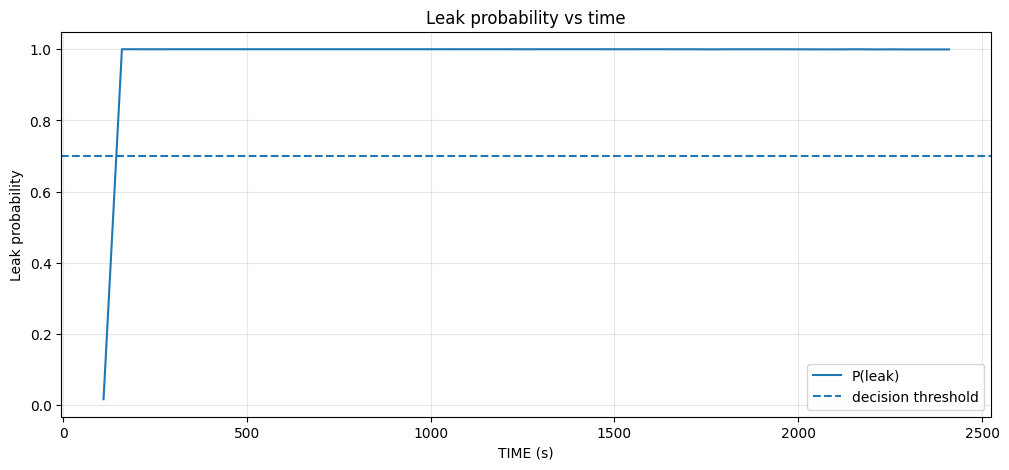

Leak score: 0.9789531


In [ ]:
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
import matplotlib.pyplot as plt

# -----------------
# Load artifacts
# -----------------
model = tf.keras.models.load_model("lstm_leak_classifier.keras")
scaler = joblib.load("scaler.pkl")
config = joblib.load("config.pkl")

feature_cols = config["feature_cols"]
T = config["time_steps"]
STRIDE = config["stride"]

TIME_COL = "TIME"
BASE_DIR = "/content/NuclearPowerPlantAccidentData/Operation_csv_data/"

def make_windows(x, T, stride):
    N, F = x.shape
    if N < T:
        return np.empty((0, T, F), dtype=np.float32)
    idxs = range(0, N - T + 1, stride)
    return np.stack([x[i:i+T] for i in idxs], axis=0)

def run_leak_detection(csv_path):
    # -----------------
    # Load data
    # -----------------
    df = pd.read_csv(csv_path)

    # Ensure required columns exist
    missing = [c for c in feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # -----------------
    # Extract + scale
    # -----------------
    x = df[feature_cols].values.astype(np.float32)
    x_scaled = scaler.transform(x)

    # -----------------
    # Windowing
    # -----------------
    Xw = make_windows(x_scaled, T, STRIDE)
    print("Windows:", Xw.shape)

    if len(Xw) == 0:
        print("Not enough data for one window")
        return None

    # -----------------
    # Predict
    # -----------------
    proba = model.predict(Xw, verbose=0).reshape(-1)

    # Align time with window end
    times = df[TIME_COL].values[T-1::STRIDE]

    return times, proba

times, proba = run_leak_detection(f"{BASE_DIR}FLB/10.csv")

plt.figure(figsize=(12,5))
plt.plot(times, proba, label="P(leak)")
plt.axhline(0.7, linestyle="--", label="decision threshold")
plt.xlabel("TIME (s)")
plt.ylabel("Leak probability")
plt.title("Leak probability vs time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

leak_score = np.mean(proba)
print("Leak score:", leak_score)

In [ ]:
import os
base = "/content/NuclearPowerPlantAccidentData/Operation_csv_data/"
for folder in sorted(os.listdir(base)):
    files = [f for f in os.listdir(base + folder) if f.endswith(".csv")]
    print(f"{folder:8} {len(files)} recordings")

ATWS     1 recordings
FLB      100 recordings
LACP     1 recordings
LLB      101 recordings
LOCA     100 recordings
LOCAC    100 recordings
LOF      1 recordings
LR       99 recordings
MD       100 recordings
Normal   1 recordings
RI       100 recordings
RW       100 recordings
SGATR    100 recordings
SGBTR    110 recordings
SLBIC    101 recordings
SLBOC    100 recordings
SP       1 recordings
TT       1 recordings


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!mkdir -p /content/drive/MyDrive/NPPAD
!cp -r /content/NuclearPowerPlantAccidentData/Operation_csv_data /content/drive/MyDrive/NPPAD/
!cp -r /content/NuclearPowerPlantAccidentData/Variable_Power_Data /content/drive/MyDrive/NPPAD/
print("Done!")

Done!
